In [ ]:
"""
Author: Ruby Lieber 
Affiliation: University of Bristol
Date: 23/07/2025

Description:
This notebook plots a comparison between 0.5 and 0.1 degree downsclaing at the IGR level. 
Supplementary Figure 2 in "Heat-related mortality attributable to human-induced climate change: findings from the 100 Million Brazilian Cohort". 
"""

In [ ]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import cartopy.crs as ccrs

In [2]:
# Read in observed timeseries data
obs = pd.read_parquet("/user/work/nh25161/BR_DWGD/tmean_timeseries_igr_pop_weighted_2000_2018.parquet")
# Read in downscaled model timeseries data (0.5)
downscaled = pd.read_parquet("/bp1/geog-tropical/data/BREATHE/timeseries_fix_merged/tas_MRI-ESM2-0_historical_r1i1p1f1_timeseries_2000_2018.parquet")
# Read in downscaled model timeseries data (0.1)
downscaled_01 = pd.read_parquet("/bp1/geog-tropical/data/BREATHE/downscale_damip_01/tas_MRI-ESM2-0_historical_r1i1p1f1_timeseries_igr_2000_2018.parquet")
# Read in municipality shapefile
shapefile = gpd.read_file("/bp1/geog-tropical/data/BREATHE/RG2017_rgi_20180911/RG2017_rgi.shp")

In [ ]:
# Merge temperature data onto shapefile 
obs_mean = obs.groupby('rgi', observed=True)['daily_pop_weighted_temperature'].mean().reset_index()
obs_merged = shapefile.merge(obs_mean, on='rgi')

obs_std = obs.groupby('rgi', observed=True)['daily_pop_weighted_temperature'].std().reset_index()
obs_std_merged = shapefile.merge(obs_std, on='rgi')

downscaled_mean = downscaled.groupby('rgi', observed=True)['daily_pop_weighted_temperature'].mean().reset_index()
downscaled_merged = shapefile.merge(downscaled_mean, on='rgi')

downscaled_01_mean = downscaled_01.groupby('rgi', observed=True)['daily_pop_weighted_temperature'].mean().reset_index()
downscaled_01_merged = shapefile.merge(downscaled_01_mean, on='rgi')

In [ ]:
# Calculate anomalies 
downscaled_anom = downscaled_merged.merge(
    obs_merged[['rgi', 'daily_pop_weighted_temperature']],
    on='rgi',
    suffixes=('_downscaled', '_obs')
)

downscaled_anom['temperature_anomaly'] = (
    downscaled_anom['daily_pop_weighted_temperature_downscaled'] - downscaled_anom['daily_pop_weighted_temperature_obs']
)

downscaled_01_anom = downscaled_01_merged.merge(
    obs_merged[['rgi', 'daily_pop_weighted_temperature']],
    on='rgi',
    suffixes=('_downscaled', '_obs')
)

# Calculate anomaly
downscaled_01_anom['temperature_anomaly'] = (
    downscaled_01_anom['daily_pop_weighted_temperature_downscaled'] - downscaled_01_anom['daily_pop_weighted_temperature_obs']
)

# Number of municipalities with greater than a degree of mean difference 
count_05 = (downscaled_anom['temperature_anomaly'].abs() > 1).sum()
count_01 = (downscaled_01_anom['temperature_anomaly'].abs() > 1).sum()

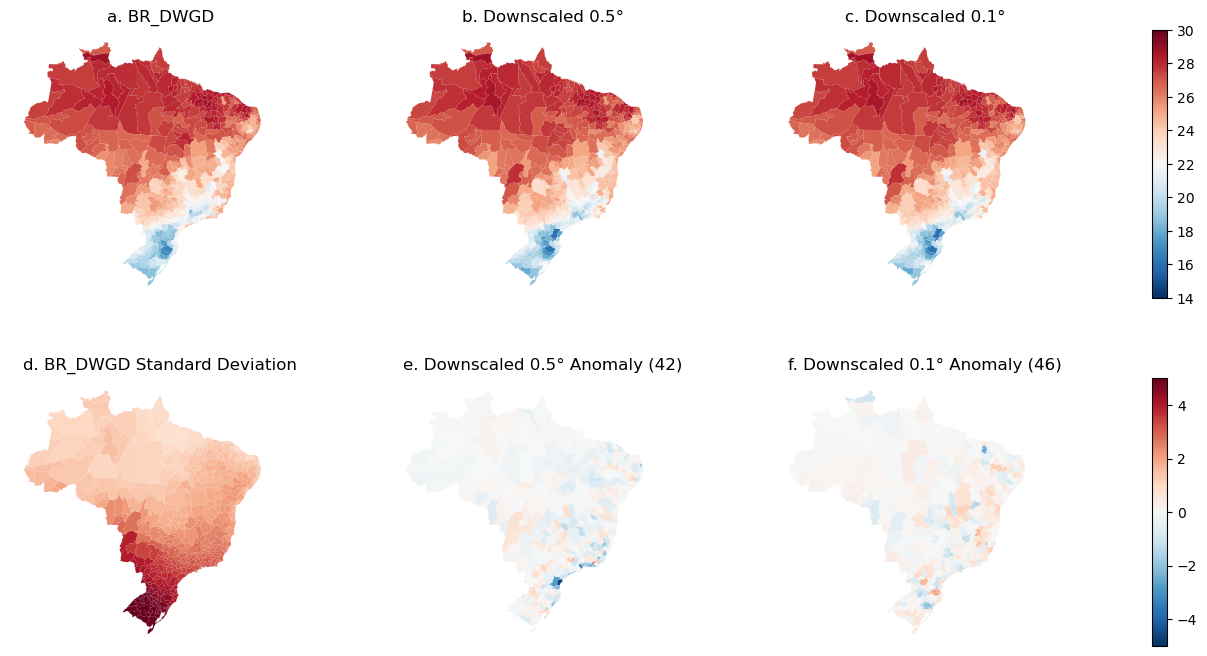

In [10]:
titles = ["a. BR_DWGD", "b. Downscaled 0.5°", "c. Downscaled 0.1°", "d. BR_DWGD Standard Deviation", 
          f"e. Downscaled 0.5° Anomaly ({count_05})", f"f. Downscaled 0.1° Anomaly ({count_01})"]

fig = plt.figure(figsize=(15, 8))

gs = gridspec.GridSpec(
    nrows=2, ncols=4,
    height_ratios=[1, 1],
    width_ratios=[1, 1, 1, 0.05], 
    hspace=0.3, wspace=0.3
)

ax1 = fig.add_subplot(gs[0, 0], projection=ccrs.PlateCarree())
im1 = obs_merged.plot(column='daily_pop_weighted_temperature', ax=ax1, cmap='RdBu_r', vmin=14, vmax=30)

ax2 = fig.add_subplot(gs[0, 1], projection=ccrs.PlateCarree())
downscaled_merged.plot(column='daily_pop_weighted_temperature', ax=ax2, cmap='RdBu_r', vmin=14, vmax=30)

ax3 = fig.add_subplot(gs[0, 2], projection=ccrs.PlateCarree())
downscaled_merged.plot(column='daily_pop_weighted_temperature', ax=ax3, cmap='RdBu_r', vmin=14, vmax=30)

ax4 = fig.add_subplot(gs[1, 0], projection=ccrs.PlateCarree())
im2 = obs_std_merged.plot(column='daily_pop_weighted_temperature', ax=ax4, cmap='RdBu_r', vmin=-5, vmax=5)

ax5 = fig.add_subplot(gs[1, 1], projection=ccrs.PlateCarree())
downscaled_anom.plot(column="temperature_anomaly", ax=ax5, cmap='RdBu_r', vmin=-5, vmax=5)

ax6 = fig.add_subplot(gs[1, 2], projection=ccrs.PlateCarree())
downscaled_01_anom.plot(column="temperature_anomaly", ax=ax6, cmap='RdBu_r', vmin=-5, vmax=5)

axes = [ax1, ax2, ax3, ax4, ax5, ax6]

for ax, title in zip(axes, titles):
    ax.set_title(title, fontsize=12)

for ax in axes:
    for spine in ax.spines.values():
        spine.set_visible(False) 

# Colorbars
cax1 = fig.add_subplot(gs[0, 3])  
fig.colorbar(im1.get_children()[0], cax=cax1, orientation='vertical')

cax2 = fig.add_subplot(gs[1, 3]) 
fig.colorbar(im2.get_children()[0], cax=cax2, orientation='vertical')